# [Demo] Checkpoints e Short-Term Memory

Todo grafo que vimos até aqui esquece tudo assim que o `invoke` termina. Aqui fechamos essa lacuna:
o estado passa a sobreviver entre execuções, isolado por paciente, dá pra voltar no tempo, e sobrevive até
ao fim do processo.

O que vamos ver:
- a amnésia de um grafo sem checkpointer;
- `InMemorySaver` e o `thread_id` obrigatório;
- isolamento entre conversas de pacientes diferentes;
- `get_state_history`, o histórico auditável do grafo;
- replay: reexecutar a partir de um checkpoint passado;
- o mesmo checkpointer num `create_agent`, com contexto e `thread_id` juntos;
- `SqliteSaver`: memória que sobrevive ao fim do processo.

## Setup

Carregamos as libs, as variáveis de ambiente (a chave `OPENAI_API_KEY` vem do `.env`) e inicializamos o modelo uma vez.

In [1]:
import sqlite3
from dataclasses import dataclass
from pathlib import Path
from IPython.display import Image, display
from langchain.agents import create_agent
from langchain.messages import SystemMessage, HumanMessage
from langchain.tools import ToolRuntime, tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## Um grafo de conversa

O mesmo formato do notebook de `StateGraph`: um nó, `MessagesState`, sem persistência ainda.

In [4]:
def answer(state: MessagesState) -> dict:
    return {"messages": model.invoke(state["messages"])}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("answer", answer)
builder.add_edge(START, "answer")
builder.add_edge("answer", END)

In [6]:
graph = builder.compile()

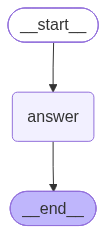

In [7]:
display(Image(graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

## A amnésia sem checkpointer

Sem persistência, cada `invoke` é uma execução isolada. A segunda chamada não tem como saber o que
aconteceu na primeira, mesmo que seja a mesma paciente falando de novo.

In [8]:
system_message = SystemMessage(
    "Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva."
)

In [9]:
response = graph.invoke({
    "messages": [
        system_message, 
        HumanMessage("Meu nome é Ana. Quero saber sobre cardiologia.")]
})
print(response["messages"][-1].content)

Olá, Ana! A cardiologia é a especialidade médica que se dedica ao diagnóstico e tratamento de doenças do coração e do sistema circulatório. Se precisar de informações específicas ou agendar uma consulta, estou à disposição para ajudar!


In [ ]:
response = graph.invoke({
    "messages": [
        system_message,
        HumanMessage("Qual é o meu nome?")]
})
print(response["messages"][-1].content)

Desculpe, mas não tenho acesso a informações pessoais. Como posso ajudar você hoje?


## InMemorySaver: guardando o estado

Um checkpointer intercepta cada passo do grafo e salva uma cópia do estado. Para o notebook, usamos
`InMemorySaver`, o simulador em memória. Ele entra na hora da compilação, o resto do grafo não muda.

In [11]:
checkpointer = InMemorySaver()

In [12]:
graph = builder.compile(checkpointer=checkpointer)

## thread_id: identificando a conversa

Com um checkpointer, o `invoke` exige um `thread_id` em `config["configurable"]`. É essa string que
identifica de quem é a conversa e onde o checkpointer deve procurar o histórico.

In [13]:
config_ana = {"configurable": {"thread_id": "ana"}}

In [ ]:
response = graph.invoke(
    input={"messages": [
        system_message, 
        HumanMessage("Meu nome é Ana. Quero saber sobre cardiologia.")
    ]},
    config=config_ana,
)
print(response["messages"][-1].content)

Olá, Ana! A cardiologia é a especialidade médica que se dedica ao diagnóstico e tratamento de doenças do coração e do sistema circulatório. Se precisar de informações específicas ou agendar uma consulta, estou à disposição para ajudar!


In [15]:
response = graph.invoke(
    input={
        "messages": [HumanMessage("Qual é o meu nome?")]
    }, 
    config=config_ana
)
print(response["messages"][-1].content)

Seu nome é Ana. Como posso ajudar você hoje?


In [16]:
response["messages"]

[SystemMessage(content='Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva.', additional_kwargs={}, response_metadata={}, id='4a2a3a06-6f95-4dff-90e4-a3174d55c085'),
 HumanMessage(content='Meu nome é Ana. Quero saber sobre cardiologia.', additional_kwargs={}, response_metadata={}, id='f14a19fe-4909-488d-80df-1d66d43ce1df'),
 AIMessage(content='Olá, Ana! A cardiologia é a especialidade médica que se dedica ao diagnóstico e tratamento de doenças do coração e do sistema circulatório. Se precisar de informações específicas ou agendar uma consulta, estou à disposição para ajudar!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 43, 'total_tokens': 89, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provid

Sem `thread_id`, o checkpointer não sabe onde guardar nem de onde ler o estado.

In [17]:
try:
    graph.invoke({"messages": [system_message, HumanMessage("Oi")]})
except Exception as error:
    print(error)

Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id


## Isolamento entre pacientes

Um `thread_id` diferente é uma conversa diferente, sem acesso ao histórico de outra paciente.

In [18]:
config_maria = {"configurable": {"thread_id": "maria"}}

In [19]:
response = graph.invoke(
    {"messages": [system_message, HumanMessage("Meu nome é Maria. Vocês atendem dermatologia?")]},
    config=config_maria,
)
print(response["messages"][-1].content)

Olá, Maria! Sim, atendemos dermatologia na Clínica Alura. Se precisar de mais informações ou agendar uma consulta, estou à disposição!


In [20]:
response = graph.invoke({"messages": [HumanMessage("Qual é o meu nome?")]}, config=config_maria)
print(response["messages"][-1].content)

Seu nome é Maria. Como posso ajudar você hoje?


In [21]:
response["messages"]

[SystemMessage(content='Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva.', additional_kwargs={}, response_metadata={}, id='4a2a3a06-6f95-4dff-90e4-a3174d55c085'),
 HumanMessage(content='Meu nome é Maria. Vocês atendem dermatologia?', additional_kwargs={}, response_metadata={}, id='5754cec9-81da-45ae-99ed-6a6aa701049e'),
 AIMessage(content='Olá, Maria! Sim, atendemos dermatologia na Clínica Alura. Se precisar de mais informações ou agendar uma consulta, estou à disposição!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 44, 'total_tokens': 74, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ef296e2731', 'id': 'c

## get_state_history: o histórico auditável

Cada passo do grafo vira um checkpoint. `get_state_history` devolve todos eles, do mais recente para o
mais antigo, o "log" completo da conversa de uma paciente.

In [22]:
history = list(graph.get_state_history(config_ana))

In [23]:
for snapshot in history:
    print(f"step={snapshot.metadata['step']} próximo={snapshot.next} mensagens={len(snapshot.values['messages'])}")

step=4 próximo=() mensagens=5
step=3 próximo=('answer',) mensagens=4
step=2 próximo=('__start__',) mensagens=3
step=1 próximo=() mensagens=3
step=0 próximo=('answer',) mensagens=2
step=-1 próximo=('__start__',) mensagens=0


In [25]:
for message in history[0].values["messages"]:
    print(f"{message.type}: {message.content}")

system: Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva.
human: Meu nome é Ana. Quero saber sobre cardiologia.
ai: Olá, Ana! A cardiologia é a especialidade médica que se dedica ao diagnóstico e tratamento de doenças do coração e do sistema circulatório. Se precisar de informações específicas ou agendar uma consulta, estou à disposição para ajudar!
human: Qual é o meu nome?
ai: Seu nome é Ana. Como posso ajudar você hoje?


## Replay: voltando no tempo

Cada checkpoint carrega o próprio `config`, com o ponto exato da execução. Invocar o grafo com
`None` e o `config` de um checkpoint passado reexecuta o grafo a partir dali.

In [26]:
before_second_answer = next(snapshot for snapshot in history if snapshot.next == ("answer",))

In [27]:
before_second_answer

StateSnapshot(values={'messages': [SystemMessage(content='Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva.', additional_kwargs={}, response_metadata={}, id='4a2a3a06-6f95-4dff-90e4-a3174d55c085'), HumanMessage(content='Meu nome é Ana. Quero saber sobre cardiologia.', additional_kwargs={}, response_metadata={}, id='f14a19fe-4909-488d-80df-1d66d43ce1df'), AIMessage(content='Olá, Ana! A cardiologia é a especialidade médica que se dedica ao diagnóstico e tratamento de doenças do coração e do sistema circulatório. Se precisar de informações específicas ou agendar uma consulta, estou à disposição para ajudar!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 43, 'total_tokens': 89, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'ca

In [28]:
before_second_answer.config

{'configurable': {'thread_id': 'ana',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19e1c1-3d25-626a-8003-f346ffc97568'}}

In [29]:
replay = graph.invoke(
    input=None, 
    config=before_second_answer.config
)
print(replay["messages"][-1].content)

Seu nome é Ana. Como posso ajudar você hoje?


O replay reexecuta o nó de verdade: a resposta pode sair com outras palavras, mas o nome da paciente
continua correto, porque já fazia parte do estado naquele checkpoint.

## O mesmo checkpointer, agora num create_agent

`checkpointer` é só mais um argumento do `create_agent`, do lado de `context_schema`. Aproveitamos e já
trocamos `InMemorySaver` por `SqliteSaver`: grava em arquivo, não em RAM. `STATE_DB` começa vazio nesta
célula só para o notebook rodar do mesmo jeito toda vez.

In [30]:
STATE_DB = Path("state.db")
STATE_DB.unlink(missing_ok=True)

In [31]:
@dataclass
class ClinicContext:
    patient_id: str
    unit: str

In [32]:
CLINIC_DB = Path("data/clinic.db")

In [33]:
def query(sql: str, params: tuple = ()) -> list[dict]:
    con = sqlite3.connect(CLINIC_DB)
    con.row_factory = sqlite3.Row
    try:
        return [dict(row) for row in con.execute(sql, params).fetchall()]
    finally:
        con.close()

In [34]:
@tool
def get_patient_record(runtime: ToolRuntime[ClinicContext]) -> str:
    """Consulta o cadastro do paciente atual, usando o patient_id do contexto de runtime."""
    rows = query("SELECT name, insurance FROM patients WHERE id = ?", (runtime.context.patient_id,))
    if not rows:
        return "Paciente não encontrado."
    return f"{rows[0]['name']}, convênio {rows[0]['insurance']}."

In [35]:
agent = create_agent(
    model=model,
    tools=[get_patient_record],
    system_prompt="Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva.",
    context_schema=ClinicContext,
    checkpointer=SqliteSaver(sqlite3.connect(STATE_DB, check_same_thread=False)),
)

## Contexto e memória juntos

Cada turno passa os dois: `context`, para a tool saber de qual paciente é o cadastro, e `config` com
`thread_id`, para o checkpointer saber de qual conversa é o histórico.

In [36]:
context_ana = ClinicContext(patient_id="123", unit="Centro")

In [37]:
config_patient_ana = {"configurable": {"thread_id": f"patient-{context_ana.patient_id}"}}

In [38]:
response = agent.invoke(
    {"messages": [HumanMessage("Qual é o meu cadastro?")]},
    context=context_ana,
    config=config_patient_ana,
)
print(response["messages"][-1].content)

Seu cadastro é: Ana Souza, convênio Alura Saúde.


In [39]:
response = agent.invoke(
    {"messages": [HumanMessage("Qual é o convênio que você me disse?")]},
    context=context_ana,
    config=config_patient_ana,
)
print(response["messages"][-1].content)

O seu convênio é Alura Saúde.


O segundo turno respondeu sem precisar chamar `get_patient_record` de novo: o checkpointer trouxe as
mensagens do turno anterior sozinho. `context_ana`, porém, teve que ser passado de novo nas duas chamadas.
O checkpointer lembra mensagens sozinho; contexto precisa ser repassado a cada `invoke`.

## A memória sobrevive a um novo processo

Para provar que a memória está no arquivo, e não só no objeto `agent` em Python, criamos um checkpointer e
um agente inteiramente novos, apontando para o mesmo `STATE_DB`. Nenhum dos dois tem qualquer referência ao
`agent` de cima.

In [40]:
fresh_checkpointer = SqliteSaver(sqlite3.connect(STATE_DB, check_same_thread=False))

In [41]:
fresh_agent = create_agent(
    model=model,
    tools=[get_patient_record],
    system_prompt="Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva.",
    context_schema=ClinicContext,
    checkpointer=fresh_checkpointer,
)

In [42]:
response = fresh_agent.invoke(
    {"messages": [HumanMessage("Qual é o convênio que você me disse?")]},
    context=context_ana,
    config=config_patient_ana,
)
print(response["messages"][-1].content)

O seu convênio é Alura Saúde.


`fresh_agent` respondeu certo sem ter participado da conversa original: leu o histórico do `STATE_DB`. É
essa diferença que faz uma CLI lembrar de uma conversa mesmo depois de fechada e aberta de novo, coisa que
`InMemorySaver` nunca conseguiria. O isolamento por `thread_id` que já vimos com o `StateGraph` continua
valendo aqui, sem precisar mostrar de novo.

## context e config["configurable"]

Os dois apareceram juntos na mesma chamada, mas resolvem problemas diferentes. `context` carrega dados que
a tool lê, como o paciente atual; muda a cada chamada e precisa ser repassado toda vez.
`config["configurable"]["thread_id"]` é o que o checkpointer usa para saber de qual conversa se trata; sem
ele, ou com um valor diferente, a conversa recomeça do zero.

## Além de um arquivo local

`SqliteSaver` resolve persistência para uma aplicação local, de um processo por vez. Para múltiplos
usuários acessando ao mesmo tempo, um checkpointer como `PostgresSaver` troca só o `checkpointer=` do
`create_agent`, sem mudar mais nada no resto do código.

## Takeaway

Estado explícito, mais um checkpointer, vira memória entre execuções e um histórico auditável, isolado por
paciente. O mecanismo é do `StateGraph`, mas o parâmetro `checkpointer` é idêntico num `create_agent`, ao
lado de `context_schema`. Trocar `InMemorySaver` por `SqliteSaver` muda onde a memória mora, de RAM para
arquivo, sem tocar em mais nada: é essa troca que faz a memória sobreviver ao fim do processo.